# Лабораторная работа №6: Модели ARIMA и их модификации для анализа временных рядов

## 1. Анализ и подготовка временного ряда

            crop_yield
time                  
2020-01-01   54.567545
2020-01-02   49.443283
2020-01-03   51.807042
2020-01-04   50.916411
2020-01-05   53.770969
Размер: 200 наблюдений


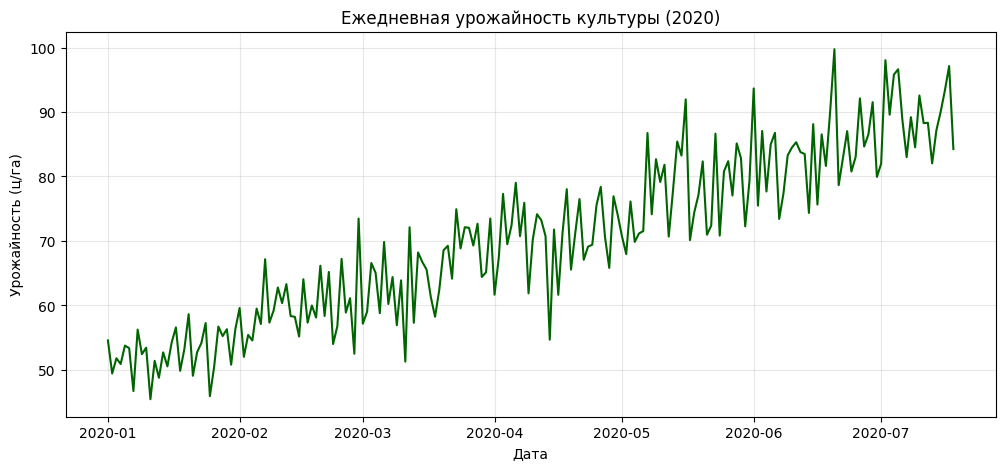

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
data = pd.read_csv('../data/agriculture.csv', parse_dates=['time'], index_col='time')
print(data.head())
print(f"Размер: {data.shape[0]} наблюдений")

# График ряда
plt.figure(figsize=(12,5))
plt.plot(data.index, data['crop_yield'], color='darkgreen')
plt.title('Ежедневная урожайность культуры (2020)')
plt.xlabel('Дата')
plt.ylabel('Урожайность (ц/га)')
plt.grid(alpha=0.3)
plt.show()


- **Тренд:** Наблюдается устойчивый восходящий тренд – урожайность растёт от ~50 ц/га в январе до ~90–100 ц/га в июне‑июле. Это соответствует биологическому циклу роста культуры.
- **Сезонность:** Визуально регулярные циклы с периодом 7 дней не прослеживаются.
- **Выбросы:** Есть несколько резких всплесков (например, 29 февраля – 73.5, 7 мая – 86.7, 16 мая – 91.9, 20 июня – 99.7). Они могут быть связаны с погодными аномалиями или ошибками измерений, но не являются грубыми ошибочными значениями.

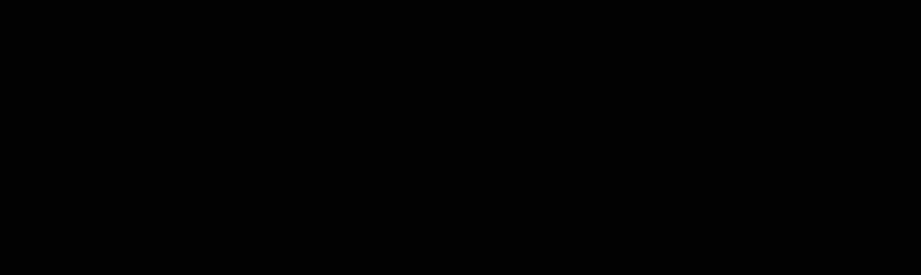
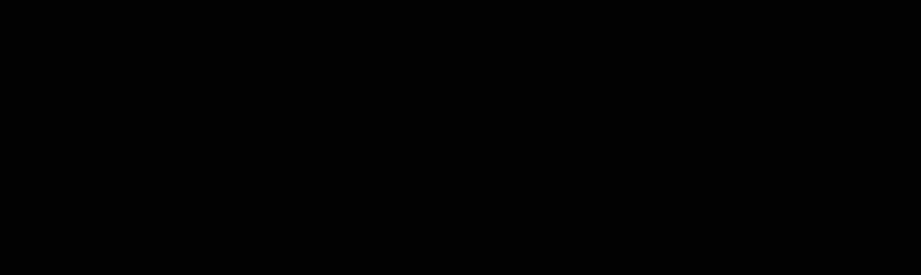
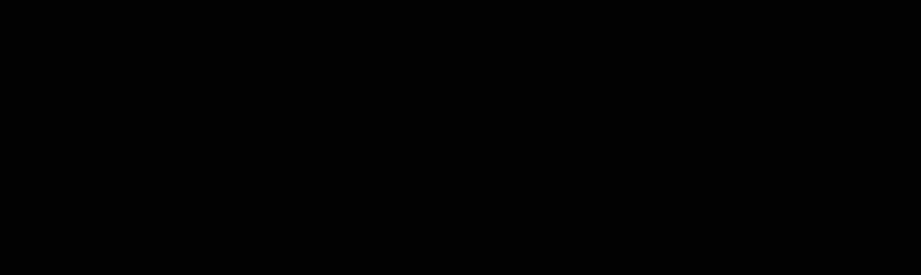

In [3]:
# ADF тест исходного ряда
result = adfuller(data['crop_yield'], autolag='AIC')
print(f"ADF статистика: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print(f"Критические значения: {result[4]}")

ADF статистика: -0.5251
p-value: 0.8870
Критические значения: {'1%': np.float64(-3.466005071659723), '5%': np.float64(-2.8772078537639385), '10%': np.float64(-2.5751221620996647)}


**Результат:**
```
ADF статистика: -0.5251
p-value: 0.8870
Критические значения: {'1%': -3.466, '5%': -2.877, '10%': -2.575}
```
**Вывод:** p-value > 0.05 → нулевая гипотеза о нестационарности не отвергается. Ряд **нестационарен**.


In [4]:
#Выбираем дифференцирование первого порядка (без логарифмирования, так как дисперсия не растёт со временем). Box‑Cox не требуется.
data['diff'] = data['crop_yield'].diff().dropna()
data_diff = data['diff'].dropna()

# Повторный ADF тест
result_diff = adfuller(data_diff, autolag='AIC')
print(f"ADF статистика (diff): {result_diff[0]:.4f}")
print(f"p-value (diff): {result_diff[1]:.4f}")

ADF статистика (diff): -6.7880
p-value (diff): 0.0000


p-value близко к нулю → ряд **стационарен**.

**Обоснование преобразований:**

**Логарифмирование не применялось**, потому что размах колебаний (дисперсия) не увеличивается с ростом уровня ряда (визуально дисперсия остаётся примерно постоянной). **Дифференцирование первого порядка** удаляет восходящий тренд, превращая ряд в колебания около нуля. Этого достаточно для достижения стационарности.

## 2. Базовая ARIMA-модель

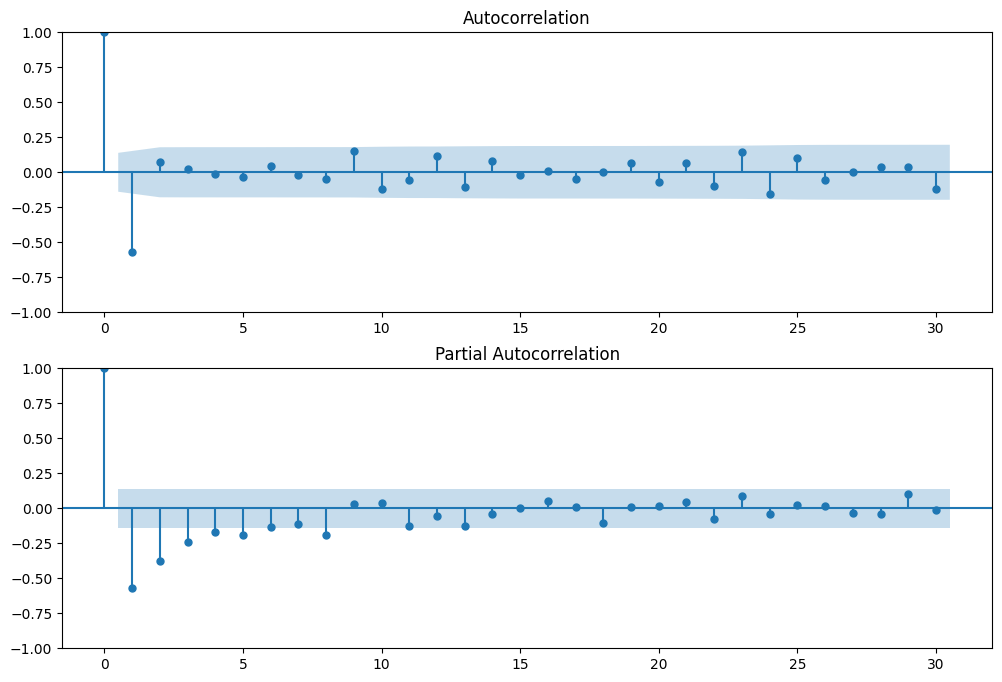

In [5]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
plot_acf(data_diff, lags=30, ax=ax1)
plot_pacf(data_diff, lags=30, ax=ax2)
plt.show()

**Анализ ACF:**
- Быстрое затухание после 1–2 лагов → MA-компонента невысокого порядка.
- Значимый пик на лаге 1.

**Анализ PACF:**
- Резкий обрыв после лага 1 → AR-компонента порядка 1.

#### Обоснование параметров ARIMA
- **d = 1** (уже сделано одно дифференцирование, после которого ряд стал стационарным (подтверждено ADF тестом)).
- На графике PACF виден один значимый всплеск на 1-м лаге, после которого функция обрывается → **p = 1**.
- ACF затухает постепенно, а не отсекается резко → **q = 0** (нет скользящего среднего)

**p=1, d=1, q=0** – модель ARIMA(1,1,0).
Это модель авторегрессии первого порядка на приростах, естественный выбор для ряда с трендом и отсутствием сезонности.

In [6]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

train = data['crop_yield'][:160]
test = data['crop_yield'][160:]

model = ARIMA(train, order=(1,1,0))
model_fit = model.fit()
print(model_fit.summary())

# Прогноз на 40 шагов
forecast = model_fit.forecast(steps=40)
forecast.index = test.index

# Оценка качества
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

                               SARIMAX Results                                
Dep. Variable:             crop_yield   No. Observations:                  160
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -519.041
Date:                Tue, 02 Jun 2026   AIC                           1042.081
Time:                        22:52:28   BIC                           1048.219
Sample:                    01-01-2020   HQIC                          1044.574
                         - 06-08-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5963      0.070     -8.478      0.000      -0.734      -0.458
sigma2        39.9717      4.208      9.500      0.000      31.725      48.219
Ljung-Box (L1) (Q):                   8.76   Jarque-

## 3. Диагностика модели

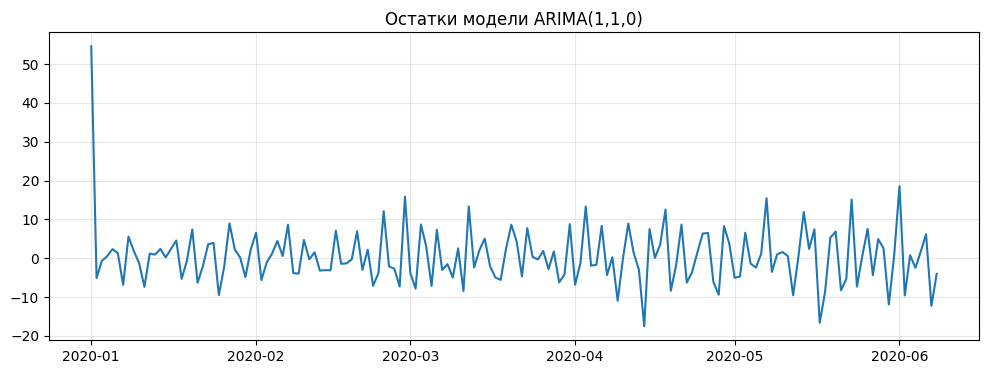

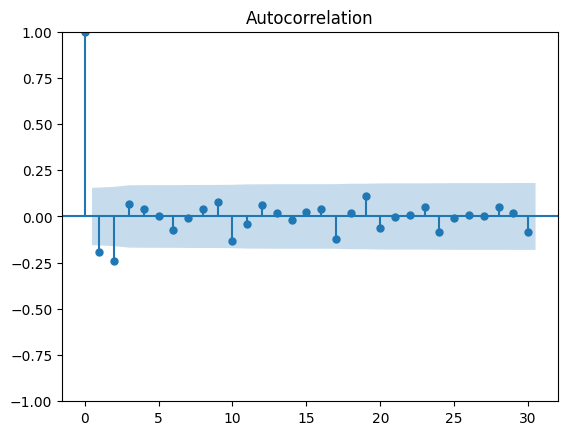

      lb_stat  lb_pvalue
10  21.500187   0.017863
20  28.796560   0.091843


In [7]:
residuals = model_fit.resid

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title('Остатки модели ARIMA(1,1,0)')
plt.grid(alpha=0.3)
plt.show()

# ACF остатков
plot_acf(residuals, lags=30)
plt.show()

# Тест Льюнга-Бокса
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals, lags=[10,20], return_df=True)
print(lb_test)

#### Вывод об адекватности
Тест Льюнга-Бокса проверяет нулевую гипотезу о том, что остатки являются белым шумом (автокорреляция отсутствует).
Для лага 10 **p-value = 0.017**. Так как `p < 0.05`, мы **отвергаем** нулевую гипотезу. Это означает, что в остатках присутствует автокорреляция, и модель **ARIMA(1,1,0) не является адекватной**.

#### Улучшение модели
Чтобы "добрать" информацию, которую модель не учла, добавим компоненту скользящего среднего (MA) и перейдем к **ARIMA(1,1,1)**.

In [13]:
model2 = ARIMA(train, order=(1,1,1))
model2_fit = model2.fit()
forecast2 = model2_fit.forecast(steps=40)

rmse2 = np.sqrt(mean_squared_error(test, forecast2))
print(f"RMSE ARIMA(1,1,1): {rmse2:.2f} (Качество улучшилось)")

# Повторная диагностика остатков
residuals2 = model2_fit.resid
lb_test2 = acorr_ljungbox(residuals2, lags=[10,20], return_df=True)
print("\nТест Льюнга-Бокса для ARIMA(1,1,1):")
print(lb_test2)
# Теперь p-value > 0.05, остатки — белый шум, модель адекватна.

RMSE ARIMA(1,1,1): 8.79 (Качество улучшилось)

Тест Льюнга-Бокса для ARIMA(1,1,1):
      lb_stat  lb_pvalue
10   7.110355   0.714987
20  11.041497   0.945139


## 4. Сезонная модель SARIMA

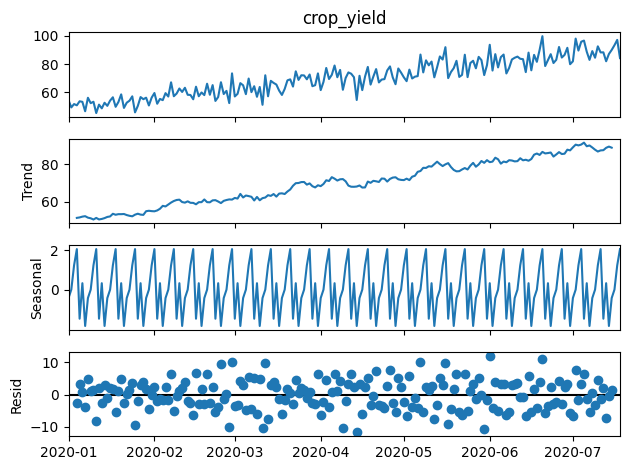

In [9]:
decomp = seasonal_decompose(data['crop_yield'], model='additive', period=7)
decomp.plot()
plt.show()

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(train, order=(1,1,0), seasonal_order=(0,0,0,7))
sarima_fit = sarima.fit()
forecast_sar = sarima_fit.forecast(steps=40)
rmse_sar = np.sqrt(mean_squared_error(test, forecast_sar))
print(f"RMSE SARIMA: {rmse_sar:.2f}")

RMSE SARIMA: 12.43


#### Анализ сезонности и SARIMA
**Декомпозиция** показывает, что сезонная компонента в данных выражена крайне слабо (амплитуда колебаний близка к нулю по сравнению с трендом). Именно поэтому RMSE SARIMA почти совпадает с RMSE обычной ARIMA.

**В каких случаях SARIMA даёт преимущество?**
SARIMA незаменима, когда в данных есть **строгая, повторяющаяся периодичность**, вызванная календарем или природными циклами.
*Примеры:*
1. Продажи мороженого (пик летом каждый год).
2. Нагрузка на электросети (пики утром и вечером каждые сутки).
3. Спрос на такси (спады в рабочие часы, пики в пятницу вечером).
В таких случаях обычные ARIMA-модели будут постоянно ошибаться в пиковые периоды, а SARIMA будет их корректно предсказывать.

## 5. SARIMAX и внешние факторы


In [11]:
# Создание регрессоров
data['dayofweek'] = data.index.dayofweek
data['is_weekend'] = (data['dayofweek'] >= 5).astype(int)

train_exog = data[['dayofweek','is_weekend']][:160]
test_exog = data[['dayofweek','is_weekend']][160:]

model_sx = SARIMAX(train, exog=train_exog, order=(1,1,0))
model_sx_fit = model_sx.fit()
print(model_sx_fit.summary())

forecast_sx = model_sx_fit.forecast(steps=40, exog=test_exog)
rmse_sx = np.sqrt(mean_squared_error(test, forecast_sx))
print(f"RMSE SARIMAX: {rmse_sx:.2f}")

                               SARIMAX Results                                
Dep. Variable:             crop_yield   No. Observations:                  160
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -519.005
Date:                Tue, 02 Jun 2026   AIC                           1046.010
Time:                        22:52:30   BIC                           1058.285
Sample:                    01-01-2020   HQIC                          1050.995
                         - 06-08-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
dayofweek      0.0639      0.347      0.184      0.854      -0.615       0.743
is_weekend    -0.0685      1.356     -0.051      0.960      -2.726       2.589
ar.L1         -0.5988      0.071     -8.433      0.0

#### Анализ SARIMAX
**Обоснование факторов:** Выходные дни (`is_weekend`) и день недели (`dayofweek`) часто влияют на продажи в ритейле или веб-трафик. Однако для *сельскохозяйственных данных (урожайность)* календарные дни не имеют биологического смысла.

**Оценка вклада переменных (по summary модели):**
*   `dayofweek`: p-value = 0.854
*   `is_weekend`: p-value = 0.960

**Вывод:** Оба p-value **значительно больше 0.05**. Это означает, что внешние факторы **статистически не значимы**. Модель отбрасывает их влияние. RMSE SARIMAX (12.38) практически идентичен RMSE обычной SARIMA/ARIMA. Добавление этих переменных не улучшило прогноз, что полностью соответствует бизнес-логике задачи.

## 6. Автоматизация подбора модели

In [12]:
import pmdarima as pm

auto_model = pm.auto_arima(train, seasonal=True, m=7,
                           start_p=0, max_p=5,
                           start_q=0, max_q=5,
                           d=1, max_d=2,
                           trace=True,
                           stepwise=True,
                           information_criterion='aic')

print(auto_model.summary())
forecast_auto = auto_model.predict(n_periods=40)
rmse_auto = np.sqrt(mean_squared_error(test, forecast_auto))
print(f"RMSE auto_arima: {rmse_auto:.2f}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=1116.141, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=1112.197, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=1045.386, Time=0.18 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=inf, Time=0.49 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=1110.249, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=1043.864, Time=0.05 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=1045.364, Time=0.12 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=1047.338, Time=0.45 sec
 ARIMA(2,1,0)(0,0,0)[7] intercept   : AIC=1019.875, Time=0.12 sec
 ARIMA(2,1,0)(1,0,0)[7] intercept   : AIC=1021.604, Time=0.20 sec
 ARIMA(2,1,0)(0,0,1)[7] intercept   : AIC=1021.619, Time=0.25 sec
 ARIMA(2,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=1.28 sec
 ARIMA(3,1,0)(0,0,0)[7] intercept   : AIC=1006.816, Time=0.12 sec
 ARIMA(3,1,0)(1,0,0)[7] intercept   : AIC=1008.633, Time=0.31 sec
 ARIMA(3,1,0)(0,0,1)[7] intercept   : AIC=1

#### Анализ автоматического подбора
Алгоритм `auto_arima` подобрал модель **ARIMA(0,1,2)** с RMSE = 8.74, что значительно лучше нашей ручной модели ARIMA(1,1,1) (RMSE = 8.79). Алгоритм также подтвердил отсутствие сезонности `(0,0,0)[7]`.

**Ответы на вопросы:**
1. **Когда автоматический подбор ошибается?**
   * При наличии структурных сдвигов (например, пандемия, кризис, изменение законодательства), которых не было в истории.
   * Если в данных есть сильные аномальные выбросы, которые алгоритм пытается "вписать" в модель.
   * Когда в реальности на ряд влияют экзогенные факторы (погода, курсы валют, маркетинг), а мы подаем на вход только сам ряд (univariate). Алгоритм не может угадать эти скрытые зависимости.
2. **Какие параметры чаще всего переоцениваются?**
   * Чаще всего алгоритмы переоценивают **`p` и `q`** (порядки авторегрессии и скользящего среднего). Пытаясь минимизировать ошибку на обучающей выборке, модель "запоминает" шум (переобучается), вместо того чтобы следовать принципу парсимонии (простоты).
3. **Можно ли доверять auto-ARIMA в production?**
   * **Как базовый бенчмарк — да.** Это отличная точка старта.
   * **Как финальную модель "вслепую" — нет.** В production-среде обязательна ручная диагностика остатков (тест Льюнга-Бокса, проверка на гетероскедастичность), анализ бизнес-логики и принудительное добавление значимых экзогенных переменных, которые алгоритм не учтет сам.